In [15]:
import pandas as pd
df = pd.read_csv("../data/raw/house_price_bd.csv")
df.head()



,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3.0,4.0,3,vacant,1960.0,dhaka,"৳39,000,000","Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,"৳12,500,000","Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4,vacant,2125.0,dhaka,"৳20,000,000","Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3.0,3.0,4,vacant,2687.0,dhaka,"৳47,500,000","Road No 25, Banani"


In [16]:
# Remove ৳ symbol and commas, convert to numeric
df['price'] = df['Price_in_taka'].str.replace('৳', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = df['price'].astype(float)

df[['Price_in_taka', 'price']].head()

,Price_in_taka,price
0,"৳39,000,000",39000000.0
1,"৳16,900,000",16900000.0
2,"৳12,500,000",12500000.0
3,"৳20,000,000",20000000.0
4,"৳47,500,000",47500000.0


In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/house_price_bd.csv")

df['price'] = df['Price_in_taka'].str.replace('৳','',regex=False).str.replace(',','',regex=False).astype(float)
df['price_per_sqft'] = df['price'] / df['Floor_area']
df['area'] = df['Location'].str.split(',').str[-1].str.strip()

# Drop the bad row(s) with unrealistic price
df = df[df['price'] > 100000]

# Rank areas into tiers by their actual average price/sqft
area_avg = df.groupby('area')['price_per_sqft'].transform('mean')
df['location_tier'] = pd.qcut(area_avg, q=3, labels=['standard', 'mid', 'premium'])

# Drop rows where location_tier couldn't be determined (missing location data)
df = df.dropna(subset=['location_tier'])

# Apply different inflation multipliers per data-derived tier
tier_multipliers = {'premium': 1.55, 'mid': 1.40, 'standard': 1.30}
df['price_adjusted'] = df.apply(lambda r: r['price'] * tier_multipliers[r['location_tier']], axis=1)

df[['area', 'location_tier', 'price', 'price_adjusted']].head(10)

,area,location_tier,price,price_adjusted
0,Gulshan,premium,39000000.0,60450000.0
1,Kalabagan,premium,16900000.0,26195000.0
2,Dhanmondi,premium,12500000.0,19375000.0
3,Bashundhara R-A,premium,20000000.0,31000000.0
4,Banani,premium,47500000.0,73625000.0
5,Badda,mid,8800000.0,12320000.0
6,Bashundhara R-A,premium,19000000.0,29450000.0
7,Bashundhara R-A,premium,23000000.0,35650000.0
8,Demra,standard,8000000.0,10400000.0
9,Aftab Nagar,mid,20000000.0,28000000.0


In [17]:
import pandas as pd

df = pd.read_csv("../data/raw/house_price_bd.csv")

# Clean price column
df['price'] = df['Price_in_taka'].str.replace('৳','',regex=False).str.replace(',','',regex=False).astype(float)

# Drop obviously bad rows (we found a ৳66 price earlier — clear data error)
df = df[df['price'] > 100000]

# Drop rows missing key fields
df = df.dropna(subset=['price', 'Floor_area', 'Location'])

# Drop exact duplicates
df = df.drop_duplicates()

# Remove extreme outliers using IQR
Q1, Q3 = df['price'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[(df['price'] >= Q1 - 1.5*IQR) & (df['price'] <= Q3 + 1.5*IQR)]

print(df.shape)
df.head()

(2554, 10)


,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location,price
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan",16900000.0
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,"৳12,500,000","Shukrabad, Dhanmondi",12500000.0
5,Modern 1150 Sq Ft Flat For Sale In Badda,3.0,3.0,3,vacant,1150.0,dhaka,"৳8,800,000","Middle Badda, Badda",8800000.0
8,Worthy 1397 Sq Ft Nice Flat Is Ready For Sale ...,3.0,3.0,8,vacant,1397.0,dhaka,"৳8,000,000","Matuail, Demra",8000000.0
10,1300 Square Feet Residential Flat With Nicely ...,3.0,3.0,3,vacant,1300.0,dhaka,"৳8,000,000","West Dolairpar, Shyampur",8000000.0


In [18]:
df.to_csv("../data/processed/cleaned.csv", index=False)

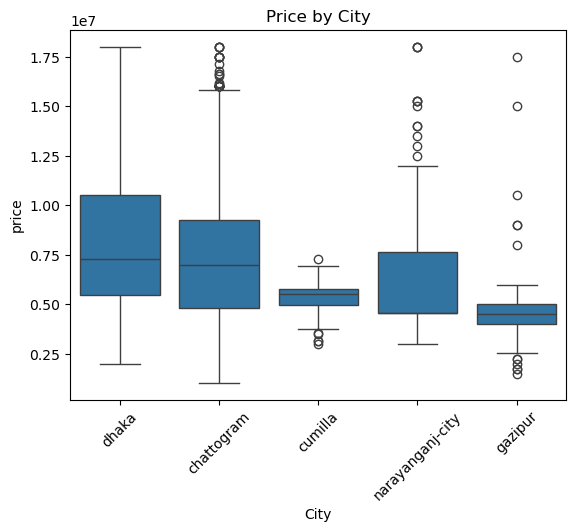

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='City', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Price by City")

plt.savefig("../data/processed/price_by_city.png", bbox_inches='tight')
plt.show()

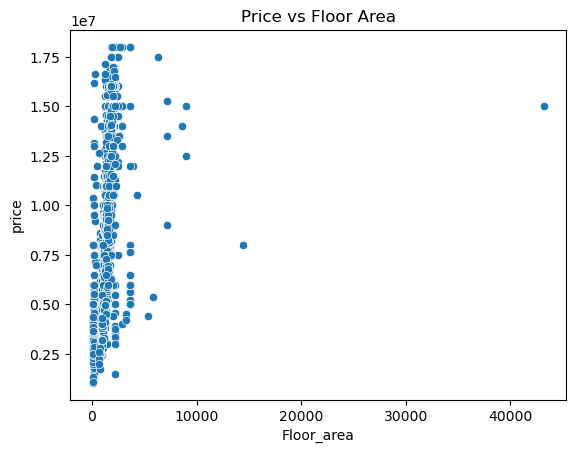

In [21]:
sns.scatterplot(x='Floor_area', y='price', data=df)
plt.title("Price vs Floor Area")

plt.savefig("../data/processed/price_by_floor_area.png", bbox_inches='tight')
plt.show()

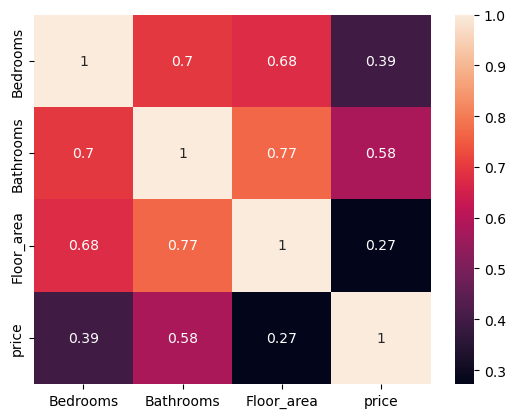

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.savefig("../data/processed/price_distribution.png", bbox_inches='tight')
plt.show()

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned.csv")

# Clean, non-leaky features only — nothing derived from price itself
df['area'] = df['Location'].str.split(',').str[-1].str.strip()
df['bed_bath_ratio'] = df['Bedrooms'] / df['Bathrooms'].replace(0, np.nan)
df['is_vacant'] = (df['Occupancy_status'].str.lower() == 'vacant').astype(int)
df['log_price'] = np.log1p(df['price'])

df.to_csv("../data/processed/features.csv", index=False)
df.head()

,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location,price,area,bed_bath_ratio,is_vacant,log_price
0,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,"৳16,900,000","Lake Circus Road, Kalabagan",16900000.0,Kalabagan,1.0,1,16.642824
1,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,"৳12,500,000","Shukrabad, Dhanmondi",12500000.0,Dhanmondi,1.0,1,16.341239
2,Modern 1150 Sq Ft Flat For Sale In Badda,3.0,3.0,3,vacant,1150.0,dhaka,"৳8,800,000","Middle Badda, Badda",8800000.0,Badda,1.0,1,15.990262
3,Worthy 1397 Sq Ft Nice Flat Is Ready For Sale ...,3.0,3.0,8,vacant,1397.0,dhaka,"৳8,000,000","Matuail, Demra",8000000.0,Demra,1.0,1,15.894952
4,1300 Square Feet Residential Flat With Nicely ...,3.0,3.0,3,vacant,1300.0,dhaka,"৳8,000,000","West Dolairpar, Shyampur",8000000.0,Shyampur,1.0,1,15.894952


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/features.csv")

feature_cols = ['Bedrooms', 'Bathrooms', 'Floor_area', 'City', 'area', 'is_vacant', 'bed_bath_ratio']
X = df[feature_cols].copy()
y = df['log_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(2043, 7) (511, 7)


In [25]:
train_with_target = X_train.copy()
train_with_target['log_price'] = y_train.values

area_median = train_with_target.groupby('area')['log_price'].median()

X_train['area_median_log_price'] = X_train['area'].map(area_median)
X_test['area_median_log_price'] = X_test['area'].map(area_median)

# fill any areas in test not seen in train with the overall median
X_test['area_median_log_price'] = X_test['area_median_log_price'].fillna(area_median.median())

X_train.head()

,Bedrooms,Bathrooms,Floor_area,City,area,is_vacant,bed_bath_ratio,area_median_log_price
2551,3.0,3.0,1350.0,gazipur,Gazipur Sadar Upazila,1,1.0,15.319588
2460,3.0,2.0,1080.0,gazipur,Gazipur Sadar Upazila,1,1.5,15.319588
1918,2.0,2.0,1050.0,cumilla,Moghultoli,1,1.0,15.236102
1905,3.0,3.0,1295.0,chattogram,Bayazid,1,1.0,15.761421
2337,NaN,NaN,3600.0,narayanganj-city,Narayanganj,1,NaN,15.336117


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

numeric_features = ['Bedrooms', 'Bathrooms', 'Floor_area', 'is_vacant', 'bed_bath_ratio', 'area_median_log_price']
categorical_features = ['City', 'area']

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

models = {
    "Linear": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe

print("All models trained.")

All models trained.


In [ ]:
import sys
!{sys.executable} -m pip install xgboost

In [35]:
import sys
print(sys.executable)


C:\GAME\anaconda\python.exe


In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

results = {}
for name, pipe in pipelines.items():
    preds_log = pipe.predict(X_test)
    preds_taka = np.expm1(preds_log)
    actual_taka = np.expm1(y_test)

    r2 = r2_score(y_test, preds_log)
    rmse_log = np.sqrt(mean_squared_error(y_test, preds_log))
    mae_taka = mean_absolute_error(actual_taka, preds_taka)
    rmse_taka = np.sqrt(mean_squared_error(actual_taka, preds_taka))

    results[name] = {"R2": r2, "RMSE_log": rmse_log, "MAE_taka": mae_taka, "RMSE_taka": rmse_taka}
    print(name, results[name])

best_model_name = max(results, key=lambda k: results[k]["R2"])
print("\nBest model:", best_model_name)

Linear {'R2': 0.6774828320819097, 'RMSE_log': np.float64(0.24064233206670144), 'MAE_taka': 1277592.7779181714, 'RMSE_taka': np.float64(2334788.6243761647)}
RandomForest {'R2': 0.8412747596344914, 'RMSE_log': np.float64(0.1688179435532178), 'MAE_taka': 802004.7310859874, 'RMSE_taka': np.float64(1243527.4733664521)}
XGBoost {'R2': 0.8380393724145802, 'RMSE_log': np.float64(0.1705298202961343), 'MAE_taka': 821218.5415851268, 'RMSE_taka': np.float64(1268735.5949915673)}

Best model: RandomForest


In [29]:
import joblib

best_pipeline = pipelines[best_model_name]
joblib.dump(best_pipeline, "../src/property_price_pipeline.pkl")
print(f"Saved {best_model_name} pipeline.")

Saved RandomForest pipeline.


In [31]:
import sys
!{sys.executable} -m pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   --------------------------------------

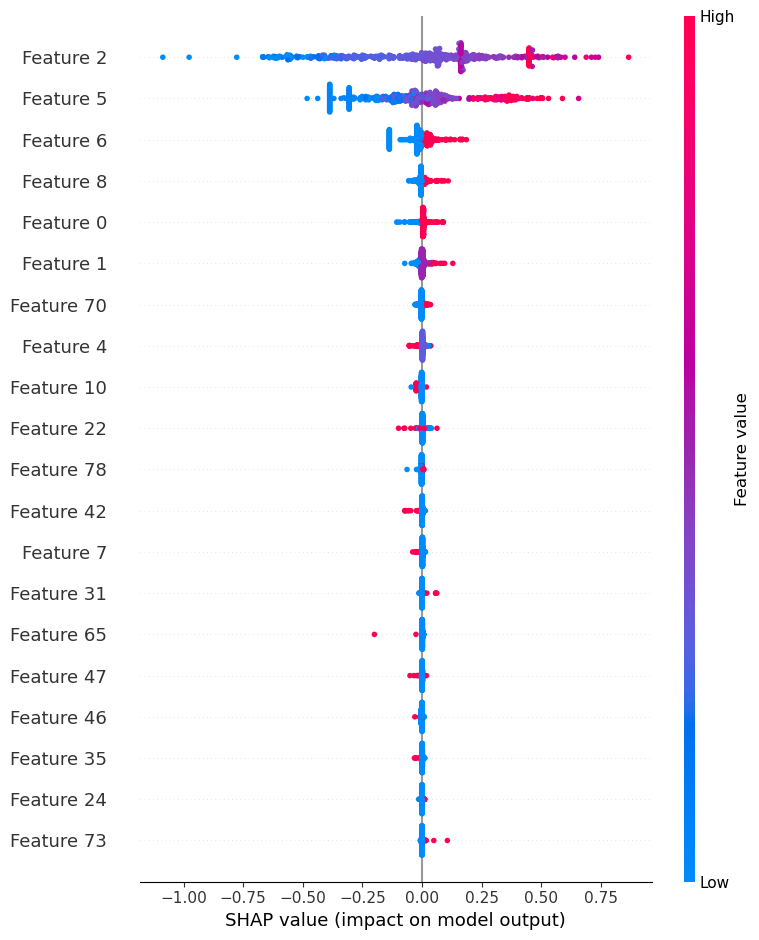

In [34]:
import numpy as np

X_test_transformed = preprocessor.transform(X_test)

# Convert to dense array if sparse, and ensure float type
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
X_test_transformed = X_test_transformed.astype(np.float64)

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed)

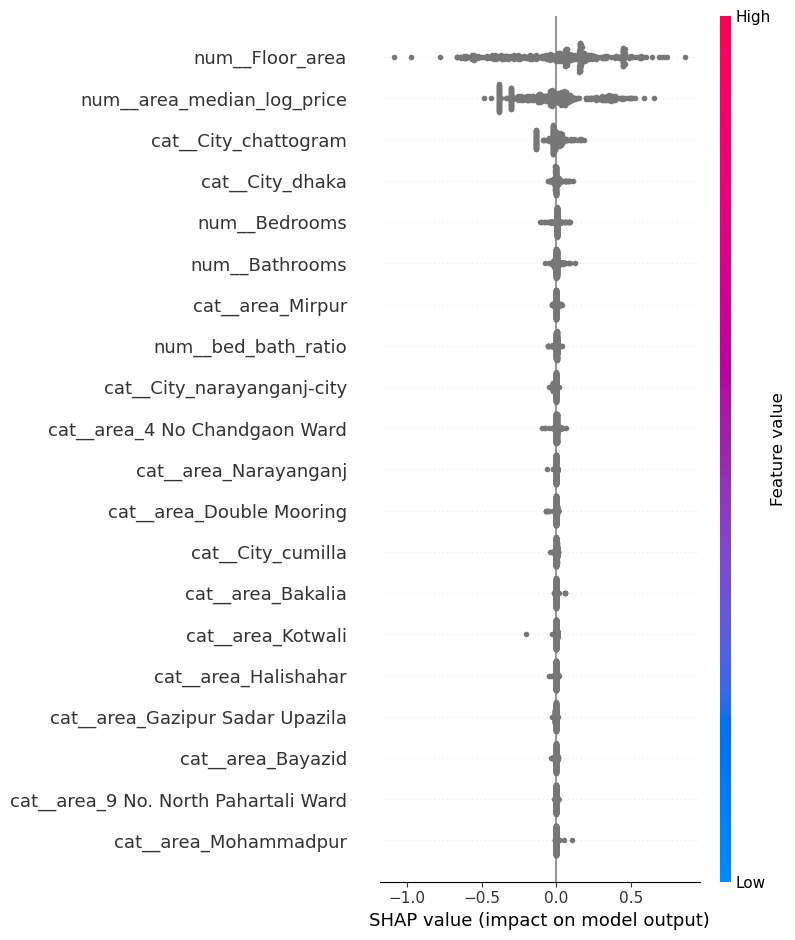

In [36]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

In [40]:
import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.savefig("../data/processed/shap_summary.png", bbox_inches='tight')

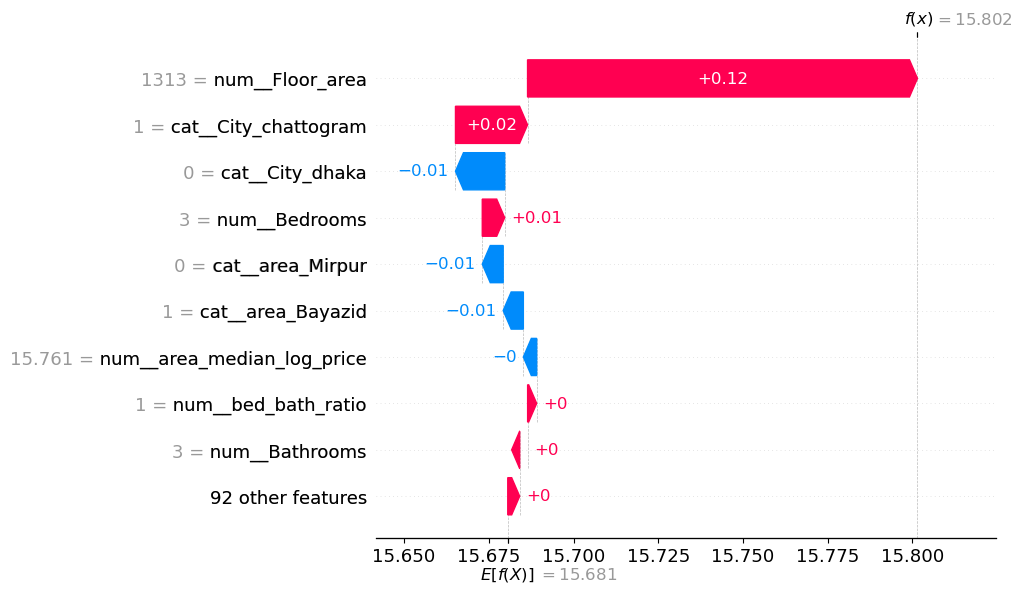

In [42]:
plt.close('all')  # clear anything left over

shap_values.feature_names = list(feature_names)
shap.plots.waterfall(shap_values[0], show=False)
plt.savefig("../data/processed/shap_waterfall_example.png", bbox_inches='tight')
plt.show()

In [43]:
print(df['City'].unique())
print(df['area'].value_counts().head(20))

['dhaka' 'chattogram' 'cumilla' 'narayanganj-city' 'gazipur']
area
Mirpur                         389
Narayanganj                    353
Gazipur Sadar Upazila          155
9 No. North Pahartali Ward     136
Bakalia                        129
Double Mooring                 114
Bayazid                         94
4 No Chandgaon Ward             93
Bashundhara R-A                 68
Khulshi                         68
Halishahar                      66
Uttara                          52
Badda                           47
Bagichagaon                     42
Sholokbahar                     42
Mohammadpur                     36
Dakshin Khan                    35
7 No. West Sholoshohor Ward     34
Muradpur                        33
15 No. Bagmoniram Ward          33
Name: count, dtype: int64


In [44]:
area_median.to_csv("../src/area_median_log_price.csv")

In [45]:
import sklearn
print(sklearn.__version__)

1.7.2
